In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Import the PlotManager
from src.plot_manager import PlotManager

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Initialize PlotManager
plot_manager = PlotManager()

print("✓ Setup complete")
print(f"✓ Plots will be saved to: {plot_manager.plots_dir}")

✓ Setup complete
✓ Plots will be saved to: data\plots


In [2]:
# Load preprocessed data
data_path = project_root / 'data' / 'processed' / 'lstm_ready_data.csv'
print(f"Loading data from: {data_path}")

df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])

print(f"\n✓ Loaded {len(df):,} records")
print(f"✓ Date range: {df['Date'].min()} to {df['Date'].max()}")

Loading data from: e:\Research Final Project\Research-Project\services\sentiment_chatbot_service\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv

✓ Loaded 245 records
✓ Date range: 2000-01-01 00:00:00 to 2020-06-01 00:00:00


INFO:src.plot_manager:Plot saved to data\plots\stock_closing_price_timeline.png
INFO:src.plot_manager:Plot index saved to data\plots\plot_index.json


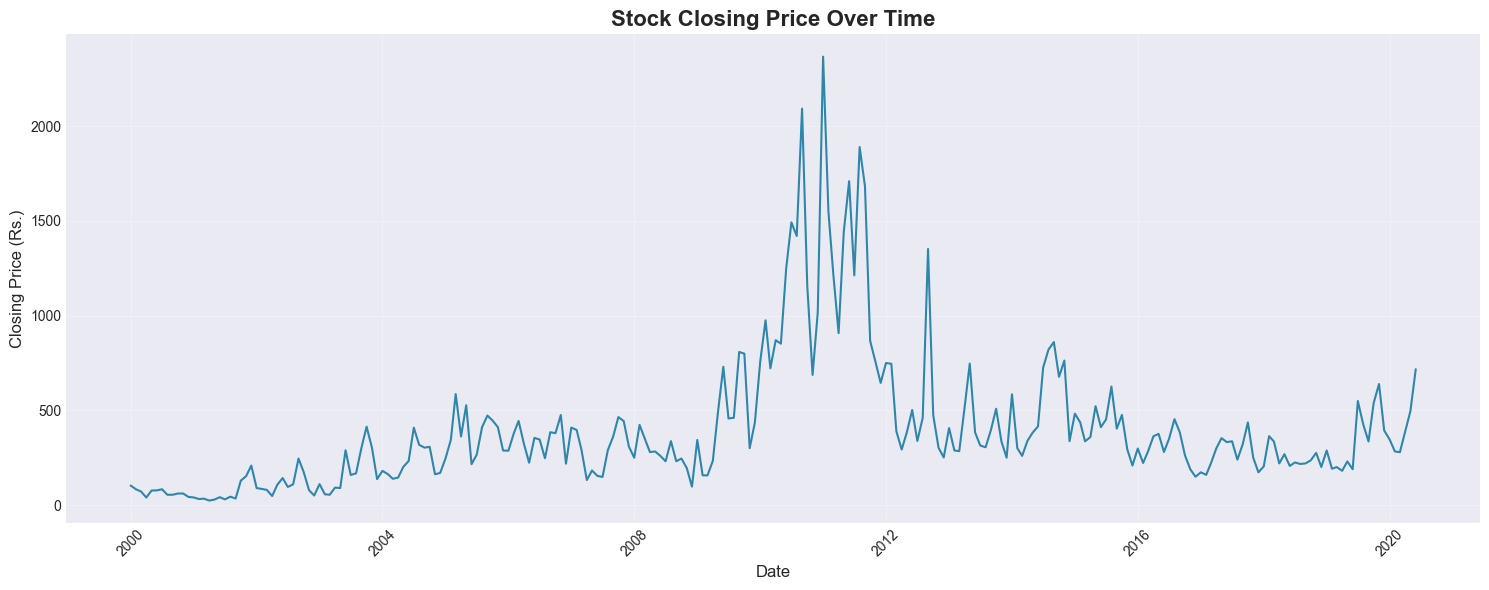

✓ Saved: Stock Closing Price Over Time


In [3]:
# Create and save closing price plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['Date'], df['Close'], linewidth=1.5, color='#2E86AB')
ax.set_title('Stock Closing Price Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Closing Price (Rs.)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plot_manager.save_plot(
    plot_id="stock_closing_price_timeline",
    title="Stock Closing Price Over Time",
    description=f"Historical stock closing prices from {df['Date'].min().date()} to {df['Date'].max().date()}. Shows the complete price trend including major peaks around 2010 (Rs. {df['Close'].max():.2f}) and overall price variations over {(df['Date'].max() - df['Date'].min()).days // 365} years.",
    keywords=["stock price", "closing price", "price trend", "historical prices", "price change", "time series", "stock performance", "price history"],
    category="price_trends",
    fig=fig
)

plt.show()
print("✓ Saved: Stock Closing Price Over Time")

INFO:src.plot_manager:Plot saved to data\plots\stock_ohlc_prices.png
INFO:src.plot_manager:Plot index saved to data\plots\plot_index.json


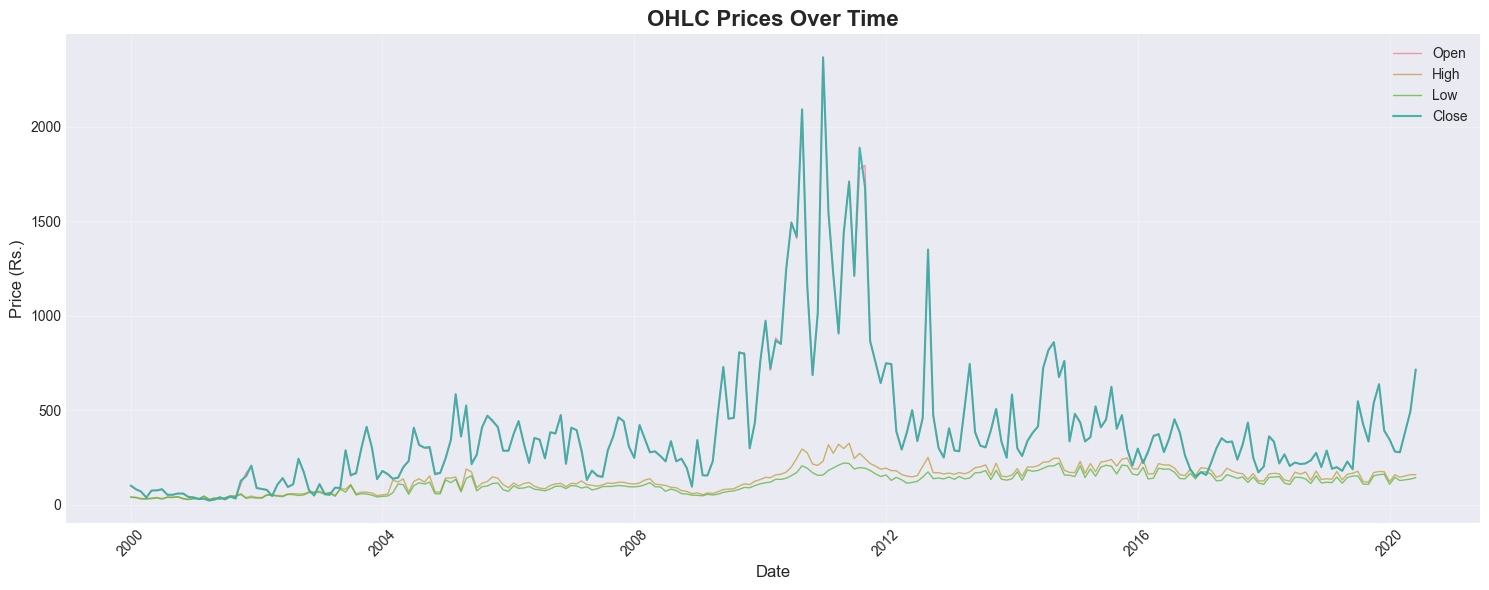

✓ Saved: OHLC Prices


In [4]:
# Create and save OHLC plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['Date'], df['Open'], label='Open', alpha=0.7, linewidth=1)
ax.plot(df['Date'], df['High'], label='High', alpha=0.7, linewidth=1)
ax.plot(df['Date'], df['Low'], label='Low', alpha=0.7, linewidth=1)
ax.plot(df['Date'], df['Close'], label='Close', alpha=0.9, linewidth=1.5)
ax.set_title('OHLC Prices Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (Rs.)', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plot_manager.save_plot(
    plot_id="stock_ohlc_prices",
    title="Open-High-Low-Close (OHLC) Prices",
    description=f"Complete OHLC price data showing opening, high, low, and closing prices over time. Useful for understanding daily price ranges and volatility. Data spans from {df['Date'].min().date()} to {df['Date'].max().date()}.",
    keywords=["OHLC", "open price", "high price", "low price", "close price", "price range", "daily prices", "volatility"],
    category="price_trends",
    fig=fig
)

plt.show()
print("✓ Saved: OHLC Prices")

INFO:src.plot_manager:Plot saved to data\plots\trading_volume_timeline.png
INFO:src.plot_manager:Plot index saved to data\plots\plot_index.json


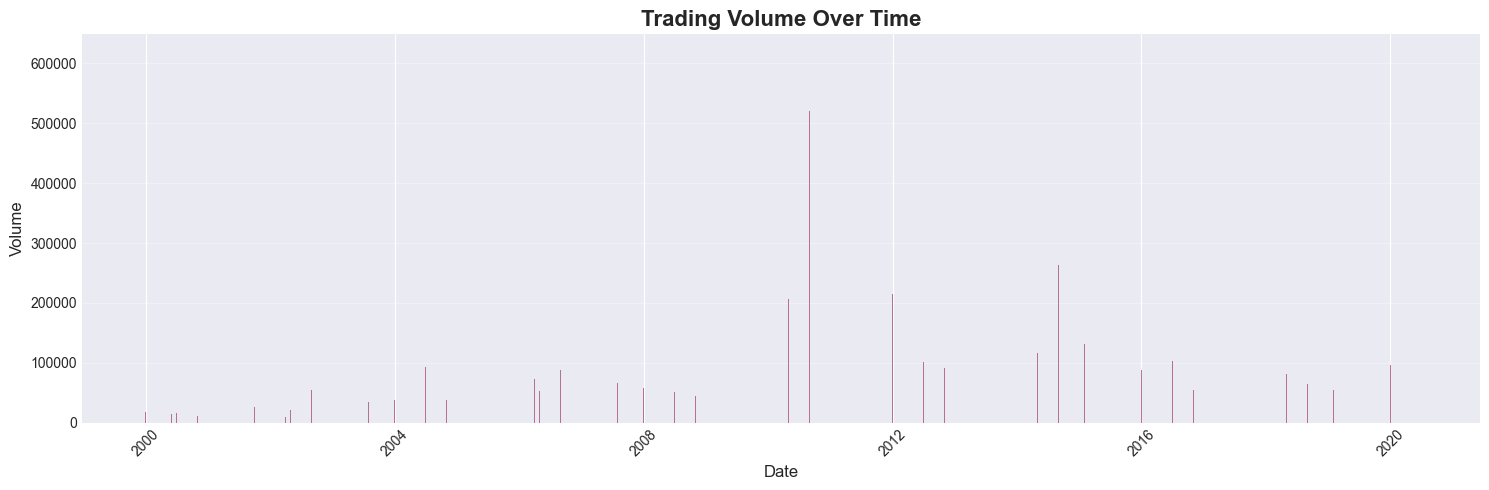

✓ Saved: Trading Volume


In [5]:
# Create and save volume plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(df['Date'], df['Volume'], color='#A23B72', alpha=0.7, width=0.8)
ax.set_title('Trading Volume Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volume', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()

plot_manager.save_plot(
    plot_id="trading_volume_timeline",
    title="Trading Volume Over Time",
    description=f"Historical trading volume showing market activity patterns. Peak volume: {df['Volume'].max():,.0f}, Average volume: {df['Volume'].mean():,.0f}. High volume periods often correlate with significant market events or price movements.",
    keywords=["trading volume", "volume", "market activity", "liquidity", "trading activity", "volume trend"],
    category="volume",
    fig=fig
)

plt.show()
print("✓ Saved: Trading Volume")

INFO:src.plot_manager:Plot saved to data\plots\price_distribution_histogram.png
INFO:src.plot_manager:Plot index saved to data\plots\plot_index.json


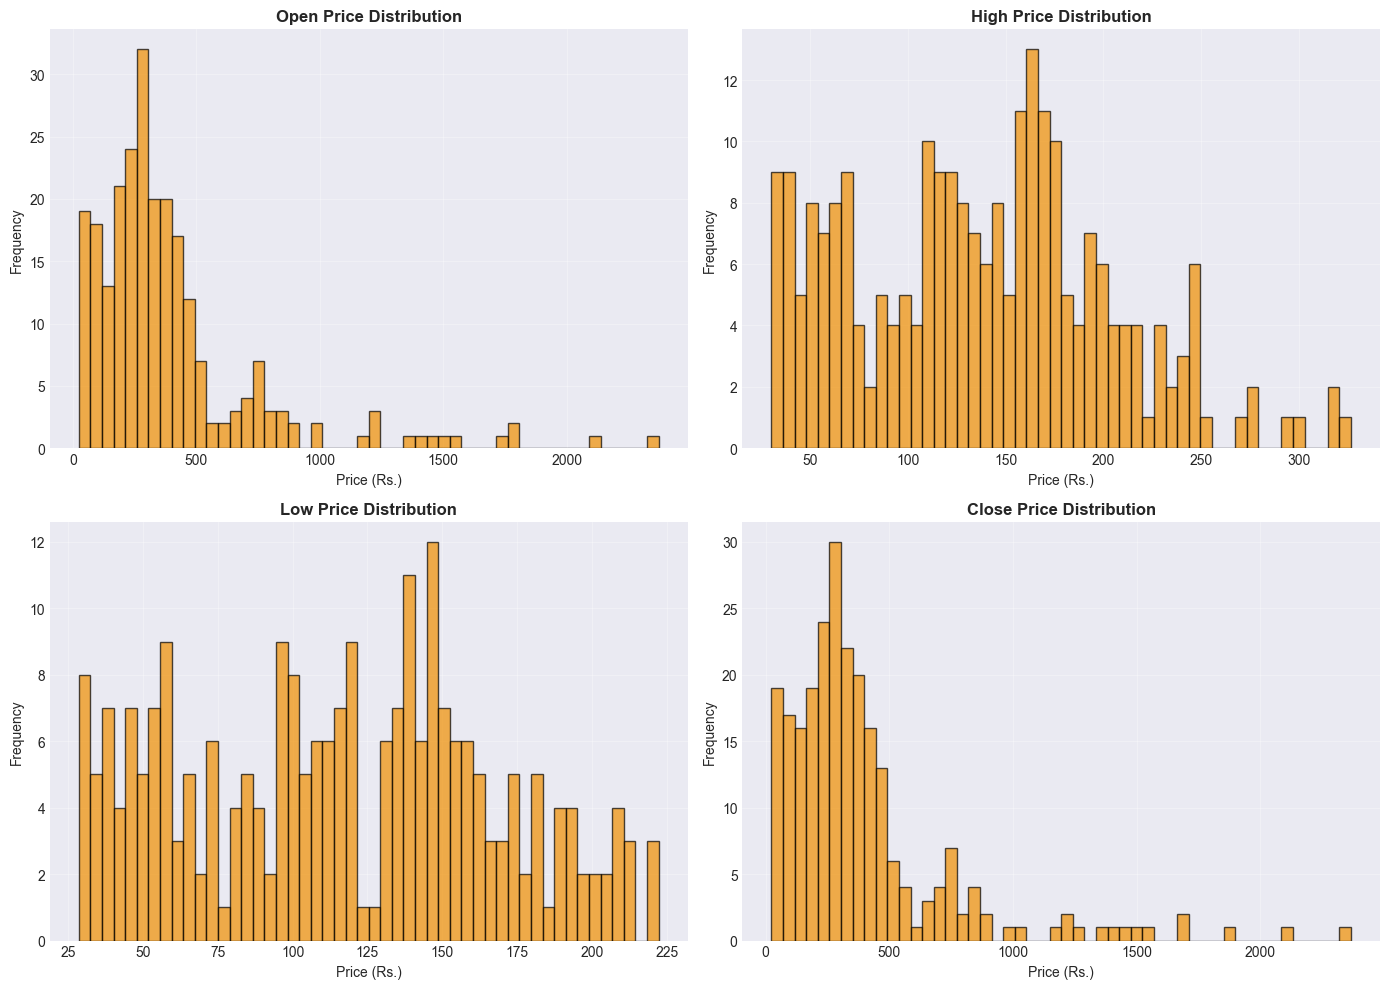

✓ Saved: Price Distribution


In [6]:
# Create and save price distribution
price_cols = ['Open', 'High', 'Low', 'Close']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(price_cols):
    axes[idx].hist(df[col], bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col} Price Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Price (Rs.)', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()

plot_manager.save_plot(
    plot_id="price_distribution_histogram",
    title="Price Distribution (OHLC)",
    description=f"Distribution of opening, high, low, and closing prices. Shows price concentration and spread. Most prices cluster around Rs. {df['Close'].median():.2f} (median), with a range from Rs. {df['Close'].min():.2f} to Rs. {df['Close'].max():.2f}.",
    keywords=["price distribution", "histogram", "price frequency", "price range", "statistical distribution"],
    category="statistical",
    fig=fig
)

plt.show()
print("✓ Saved: Price Distribution")

INFO:src.plot_manager:Plot saved to data\plots\feature_correlation_heatmap.png
INFO:src.plot_manager:Plot index saved to data\plots\plot_index.json


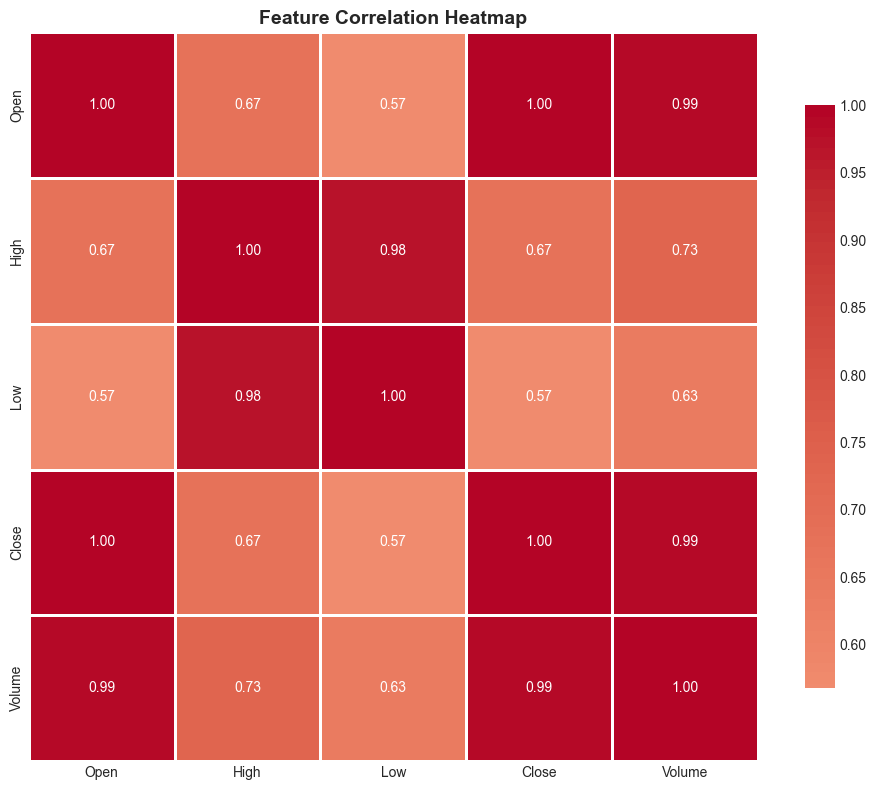

✓ Saved: Correlation Heatmap


In [7]:
# Create and save correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()

plot_manager.save_plot(
    plot_id="feature_correlation_heatmap",
    title="Feature Correlation Heatmap",
    description="Correlation matrix showing relationships between all numeric features. Strong positive correlations (close to 1.0) between OHLC prices indicate they move together. Volume correlation with price helps understand price-volume relationships.",
    keywords=["correlation", "feature correlation", "relationship", "correlation matrix", "feature relationships"],
    category="statistical",
    fig=fig
)

plt.show()
print("✓ Saved: Correlation Heatmap")

INFO:src.plot_manager:Plot saved to data\plots\daily_returns_analysis.png
INFO:src.plot_manager:Plot index saved to data\plots\plot_index.json


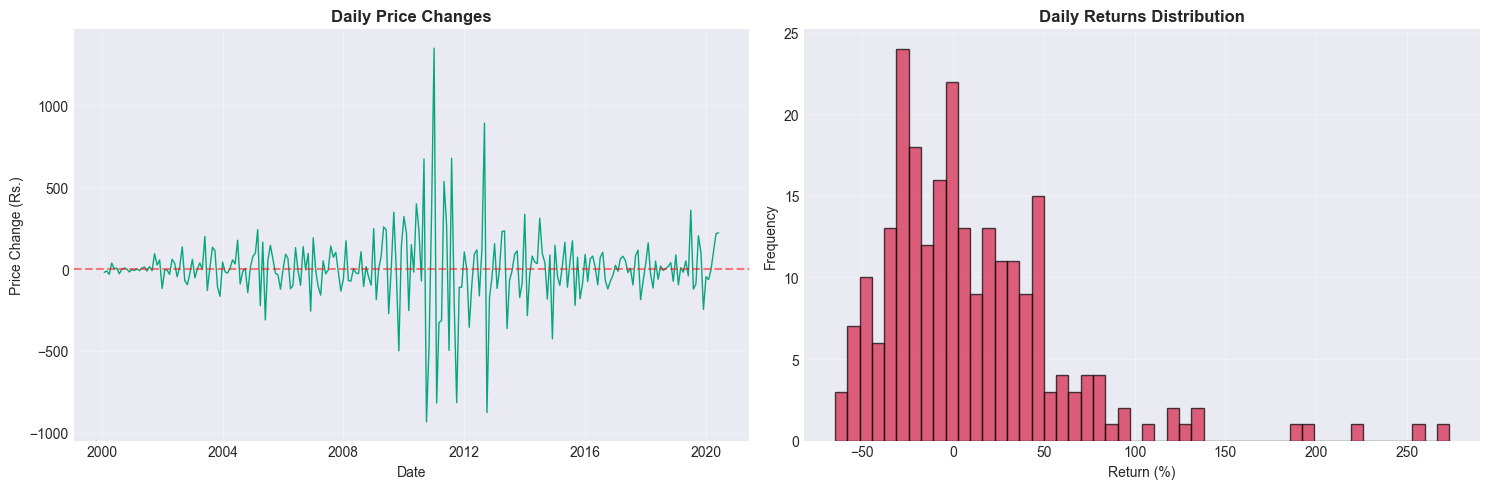

✓ Saved: Daily Returns Analysis


In [8]:
# Calculate returns
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Price_Change'] = df['Close'].diff()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Price changes
axes[0].plot(df['Date'], df['Price_Change'], linewidth=1, color='#06A77D')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Daily Price Changes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price Change (Rs.)')
axes[0].grid(True, alpha=0.3)

# Returns distribution
axes[1].hist(df['Daily_Return'].dropna(), bins=50, color='#D62246', alpha=0.7, edgecolor='black')
axes[1].set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plot_manager.save_plot(
    plot_id="daily_returns_analysis",
    title="Daily Returns and Price Changes",
    description=f"Daily price changes and return distribution. Mean daily return: {df['Daily_Return'].mean():.4f}%, Std: {df['Daily_Return'].std():.4f}%. Shows volatility patterns and typical daily movements. The distribution indicates risk and return characteristics.",
    keywords=["daily returns", "returns", "price change", "volatility", "risk", "return distribution", "profit loss"],
    category="returns",
    fig=fig
)

plt.show()
print("✓ Saved: Daily Returns Analysis")

INFO:src.plot_manager:Plot saved to data\plots\moving_averages_trend.png
INFO:src.plot_manager:Plot index saved to data\plots\plot_index.json


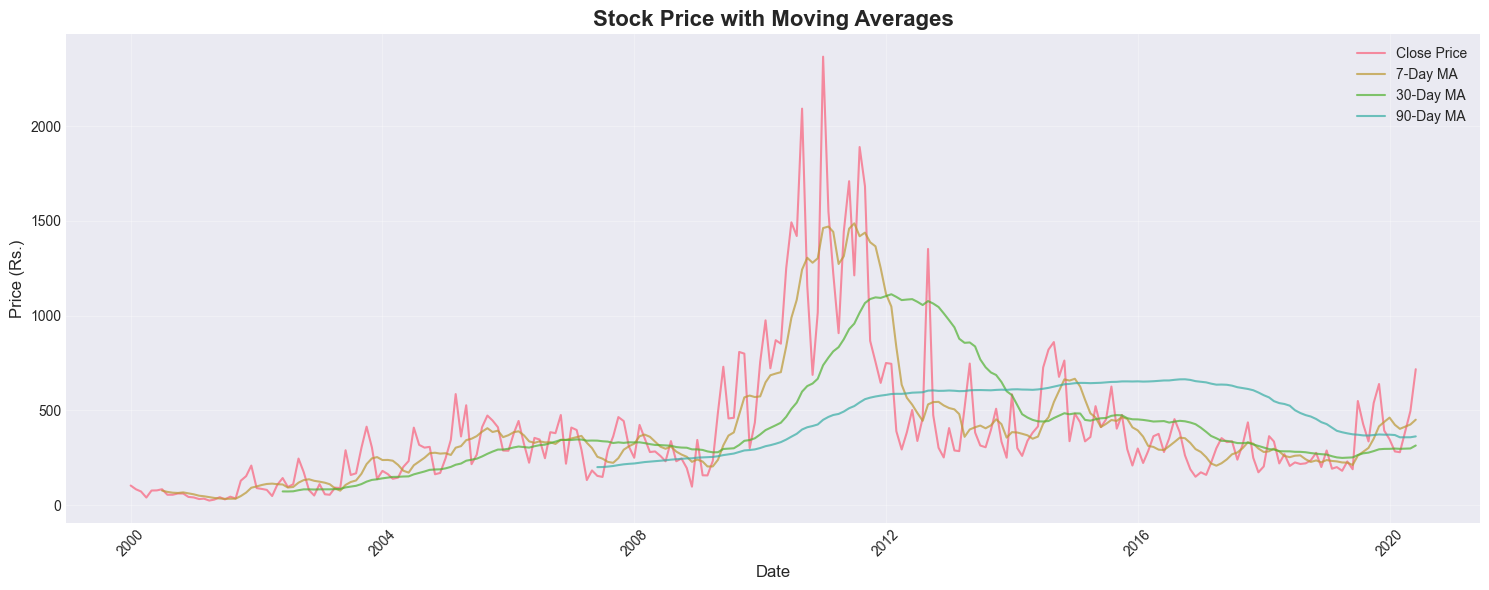

✓ Saved: Moving Averages


In [9]:
# Calculate moving averages
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['MA_90'] = df['Close'].rolling(window=90).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['Date'], df['Close'], label='Close Price', linewidth=1.5, alpha=0.8)
ax.plot(df['Date'], df['MA_7'], label='7-Day MA', linewidth=1.5, alpha=0.7)
ax.plot(df['Date'], df['MA_30'], label='30-Day MA', linewidth=1.5, alpha=0.7)
ax.plot(df['Date'], df['MA_90'], label='90-Day MA', linewidth=1.5, alpha=0.7)

ax.set_title('Stock Price with Moving Averages', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (Rs.)', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plot_manager.save_plot(
    plot_id="moving_averages_trend",
    title="Stock Price with Moving Averages",
    description="Stock closing price overlaid with 7-day, 30-day, and 90-day moving averages. Moving averages smooth out short-term fluctuations and reveal longer-term trends. Useful for trend analysis and identifying support/resistance levels.",
    keywords=["moving average", "MA", "trend", "technical analysis", "smoothing", "7-day", "30-day", "90-day"],
    category="technical_analysis",
    fig=fig
)

plt.show()
print("✓ Saved: Moving Averages")

INFO:src.plot_manager:Plot saved to data\plots\price_volatility_timeline.png
INFO:src.plot_manager:Plot index saved to data\plots\plot_index.json


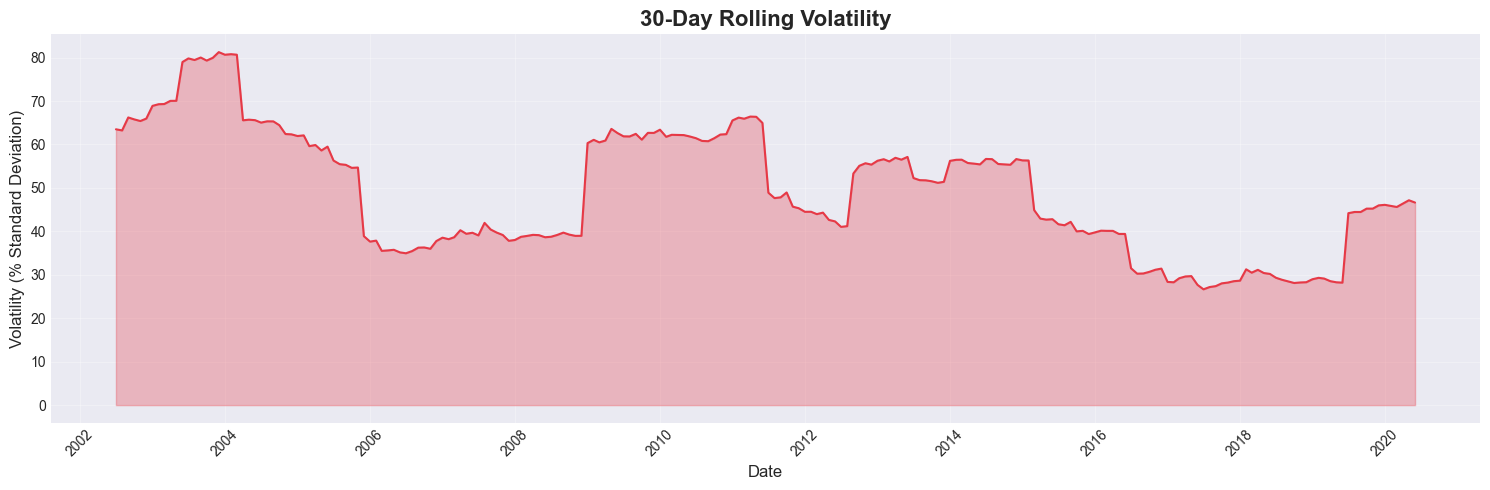

✓ Saved: Price Volatility


In [10]:
# Calculate rolling volatility (30-day standard deviation of returns)
df['Volatility_30'] = df['Daily_Return'].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['Date'], df['Volatility_30'], linewidth=1.5, color='#E63946')
ax.fill_between(df['Date'], 0, df['Volatility_30'], alpha=0.3, color='#E63946')
ax.set_title('30-Day Rolling Volatility', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (% Standard Deviation)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plot_manager.save_plot(
    plot_id="price_volatility_timeline",
    title="30-Day Rolling Volatility",
    description=f"Rolling 30-day volatility showing risk levels over time. High volatility periods indicate increased market uncertainty and risk. Peak volatility: {df['Volatility_30'].max():.2f}%, Average: {df['Volatility_30'].mean():.2f}%.",
    keywords=["volatility", "risk", "standard deviation", "market risk", "uncertainty", "volatility trend"],
    category="risk_analysis",
    fig=fig
)

plt.show()
print("✓ Saved: Price Volatility")

In [11]:
# Display plot statistics
stats = plot_manager.get_stats()

print("\n" + "=" * 60)
print("PLOT STORAGE SUMMARY")
print("=" * 60)
print(f"\nTotal plots saved: {stats['total_plots']}")
print(f"Total storage size: {stats['total_size_mb']} MB")
print(f"\nPlots by category:")
for category, count in stats['plots_per_category'].items():
    print(f"  - {category}: {count} plots")

print(f"\nIndex file: {stats['index_file']}")
print(f"Plot directory: {plot_manager.plots_dir}")

print("\n✓ All plots saved successfully!")
print("\nThese plots can now be retrieved by the RAG system based on user queries.")


PLOT STORAGE SUMMARY

Total plots saved: 8
Total storage size: 1.98 MB

Plots by category:
  - statistical: 2 plots
  - technical_analysis: 1 plots
  - risk_analysis: 1 plots
  - returns: 1 plots
  - price_trends: 2 plots
  - volume: 1 plots

Index file: data\plots\plot_index.json
Plot directory: data\plots

✓ All plots saved successfully!

These plots can now be retrieved by the RAG system based on user queries.


In [12]:
# Test: Search for plots
print("\n" + "=" * 60)
print("TESTING PLOT SEARCH")
print("=" * 60)

test_queries = [
    "stock price change over time",
    "trading volume",
    "how volatile is the stock",
    "price distribution",
    "moving averages"
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    results = plot_manager.search_plots(query, limit=2)
    for i, result in enumerate(results, 1):
        print(f"  {i}. {result['title']} (score: {result['relevance_score']})")


TESTING PLOT SEARCH

Query: 'stock price change over time'
  1. Stock Closing Price Over Time (score: 22)
  2. Daily Returns and Price Changes (score: 11)

Query: 'trading volume'
  1. Trading Volume Over Time (score: 38)
  2. Feature Correlation Heatmap (score: 2)

Query: 'how volatile is the stock'
  1. Stock Closing Price Over Time (score: 8)
  2. Daily Returns and Price Changes (score: 6)

Query: 'price distribution'
  1. Price Distribution (OHLC) (score: 21)
  2. Daily Returns and Price Changes (score: 4)

Query: 'moving averages'
  1. Stock Price with Moving Averages (score: 26)
